# Verify Segmentation Labels from convert_to_slices.py

This notebook verifies that segmentation labels generated from `convert_to_slices.py` are:
- Correctly saved and loadable
- Visible and properly aligned with ultrasound images
- Have correct shapes and data types
- Contain valid segmentation data (non-empty, proper label values)

In [1]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

## Configuration

Set the path to your output directory from `convert_to_slices.py`

In [2]:
# Set the path to your output directory from convert_to_slices.py
# This should be the --output-dir argument you used when running convert_to_slices.py
slice_data_folder = r"C:\\Users\\Gabriella\\Documents\\KidneyDataset\\Slices"  # Update this path

# Verify the folder exists
if not os.path.exists(slice_data_folder):
    print(f"ERROR: Folder not found: {slice_data_folder}")
    print("Please update the slice_data_folder variable above with the correct path.")
else:
    print(f"✓ Found data folder: {slice_data_folder}")

✓ Found data folder: C:\\Users\\Gabriella\\Documents\\KidneyDataset\\Slices


## Step 1: Find all segmentation files

In [3]:
# Get list of all segmentation files
label_dir = os.path.join(slice_data_folder, "labels")
seg_files = glob.glob(os.path.join(label_dir, "*/*.npy"), recursive=True)
seg_files = [f for f in seg_files if "segmentation" in f.lower() or "labelmap" in f.lower()]

print(f"Found {len(seg_files)} segmentation files")
if len(seg_files) > 0:
    print(f"\nFirst 5 files:")
    for f in seg_files[:5]:
        print(f"  {f}")
else:
    print(f"\nWARNING: No segmentation files found in {label_dir}")
    print("Make sure the path is correct and that convert_to_slices.py has been run.")

Found 342 segmentation files

First 5 files:
  C:\\Users\\Gabriella\\Documents\\KidneyDataset\\Slices\labels\0000\0000_segmentation.npy
  C:\\Users\\Gabriella\\Documents\\KidneyDataset\\Slices\labels\0000\0001_segmentation.npy
  C:\\Users\\Gabriella\\Documents\\KidneyDataset\\Slices\labels\0000\0002_segmentation.npy
  C:\\Users\\Gabriella\\Documents\\KidneyDataset\\Slices\labels\0000\0003_segmentation.npy
  C:\\Users\\Gabriella\\Documents\\KidneyDataset\\Slices\labels\0000\0004_segmentation.npy


## Step 2: Verify segmentation files can be loaded and check their properties

In [4]:
def load_segmentation(file_path):
    """Load segmentation file and return array with metadata"""
    try:
        arr = np.load(file_path)
        if isinstance(arr, np.lib.npyio.NpzFile):
            arr = arr[arr.files[0]]
        return arr, None
    except Exception as e:
        return None, str(e)

# Check a sample of segmentation files
print("Checking segmentation file properties...\n")
sample_size = min(10, len(seg_files))
sample_files = np.random.choice(seg_files, size=sample_size, replace=False) if len(seg_files) > 0 else []

issues = []
valid_files = []

for seg_file in sample_files:
    seg_arr, error = load_segmentation(seg_file)
    if error:
        issues.append(f"ERROR loading {seg_file}: {error}")
        continue
    
    valid_files.append((seg_file, seg_arr))
    
    # Check properties
    print(f"File: {os.path.basename(seg_file)}")
    print(f"  Shape: {seg_arr.shape}")
    print(f"  Dtype: {seg_arr.dtype}")
    print(f"  Min value: {np.min(seg_arr)}, Max value: {np.max(seg_arr)}")
    print(f"  Unique labels: {np.unique(seg_arr)}")
    print(f"  Non-zero pixels: {np.count_nonzero(seg_arr)} / {seg_arr.size} ({100*np.count_nonzero(seg_arr)/seg_arr.size:.2f}%)")
    
    # Check for potential issues
    if seg_arr.size == 0:
        issues.append(f"Empty segmentation: {seg_file}")
    if np.max(seg_arr) == 0:
        issues.append(f"No labels found (all zeros): {seg_file}")
    if seg_arr.ndim > 3:
        issues.append(f"Unexpected dimensions ({seg_arr.ndim}D): {seg_file}")
    
    print()

if issues:
    print("\n⚠️  ISSUES FOUND:")
    for issue in issues:
        print(f"  - {issue}")
else:
    print("\n✓ All checked files loaded successfully!")

Checking segmentation file properties...

File: 0227_segmentation.npy
  Shape: (256, 256, 1)
  Dtype: uint8
  Min value: 0, Max value: 1
  Unique labels: [0 1]
  Non-zero pixels: 5986 / 65536 (9.13%)

File: 0205_segmentation.npy
  Shape: (256, 256, 1)
  Dtype: uint8
  Min value: 0, Max value: 0
  Unique labels: [0]
  Non-zero pixels: 0 / 65536 (0.00%)

File: 0226_segmentation.npy
  Shape: (256, 256, 1)
  Dtype: uint8
  Min value: 0, Max value: 1
  Unique labels: [0 1]
  Non-zero pixels: 6469 / 65536 (9.87%)

File: 0134_segmentation.npy
  Shape: (256, 256, 1)
  Dtype: uint8
  Min value: 0, Max value: 2
  Unique labels: [0 1 2]
  Non-zero pixels: 7686 / 65536 (11.73%)

File: 0336_segmentation.npy
  Shape: (256, 256, 1)
  Dtype: uint8
  Min value: 0, Max value: 0
  Unique labels: [0]
  Non-zero pixels: 0 / 65536 (0.00%)

File: 0186_segmentation.npy
  Shape: (256, 256, 1)
  Dtype: uint8
  Min value: 0, Max value: 0
  Unique labels: [0]
  Non-zero pixels: 0 / 65536 (0.00%)

File: 0218_segme

## Step 3: Visualize segmentations with their corresponding ultrasound images

In [5]:
# Randomly select some files to visualize
num_samples = min(5, len(seg_files))
if len(seg_files) > 0:
    rand_files = np.random.choice(seg_files, size=num_samples, replace=False)
    
    # Get corresponding image files
    img_files = []
    for seg_file in rand_files:
        # Convert segmentation path to image path
        img_file = seg_file.replace("labels", "images").replace("segmentation", "ultrasound").replace("labelmap", "ultrasound")
        if os.path.exists(img_file):
            img_files.append(img_file)
        else:
            print(f"Warning: Image file not found for {seg_file}")
            print(f"  Expected: {img_file}")
    
    print(f"Found {len(img_files)} matching image-segmentation pairs to visualize")
else:
    rand_files = []
    img_files = []

Found 5 matching image-segmentation pairs to visualize


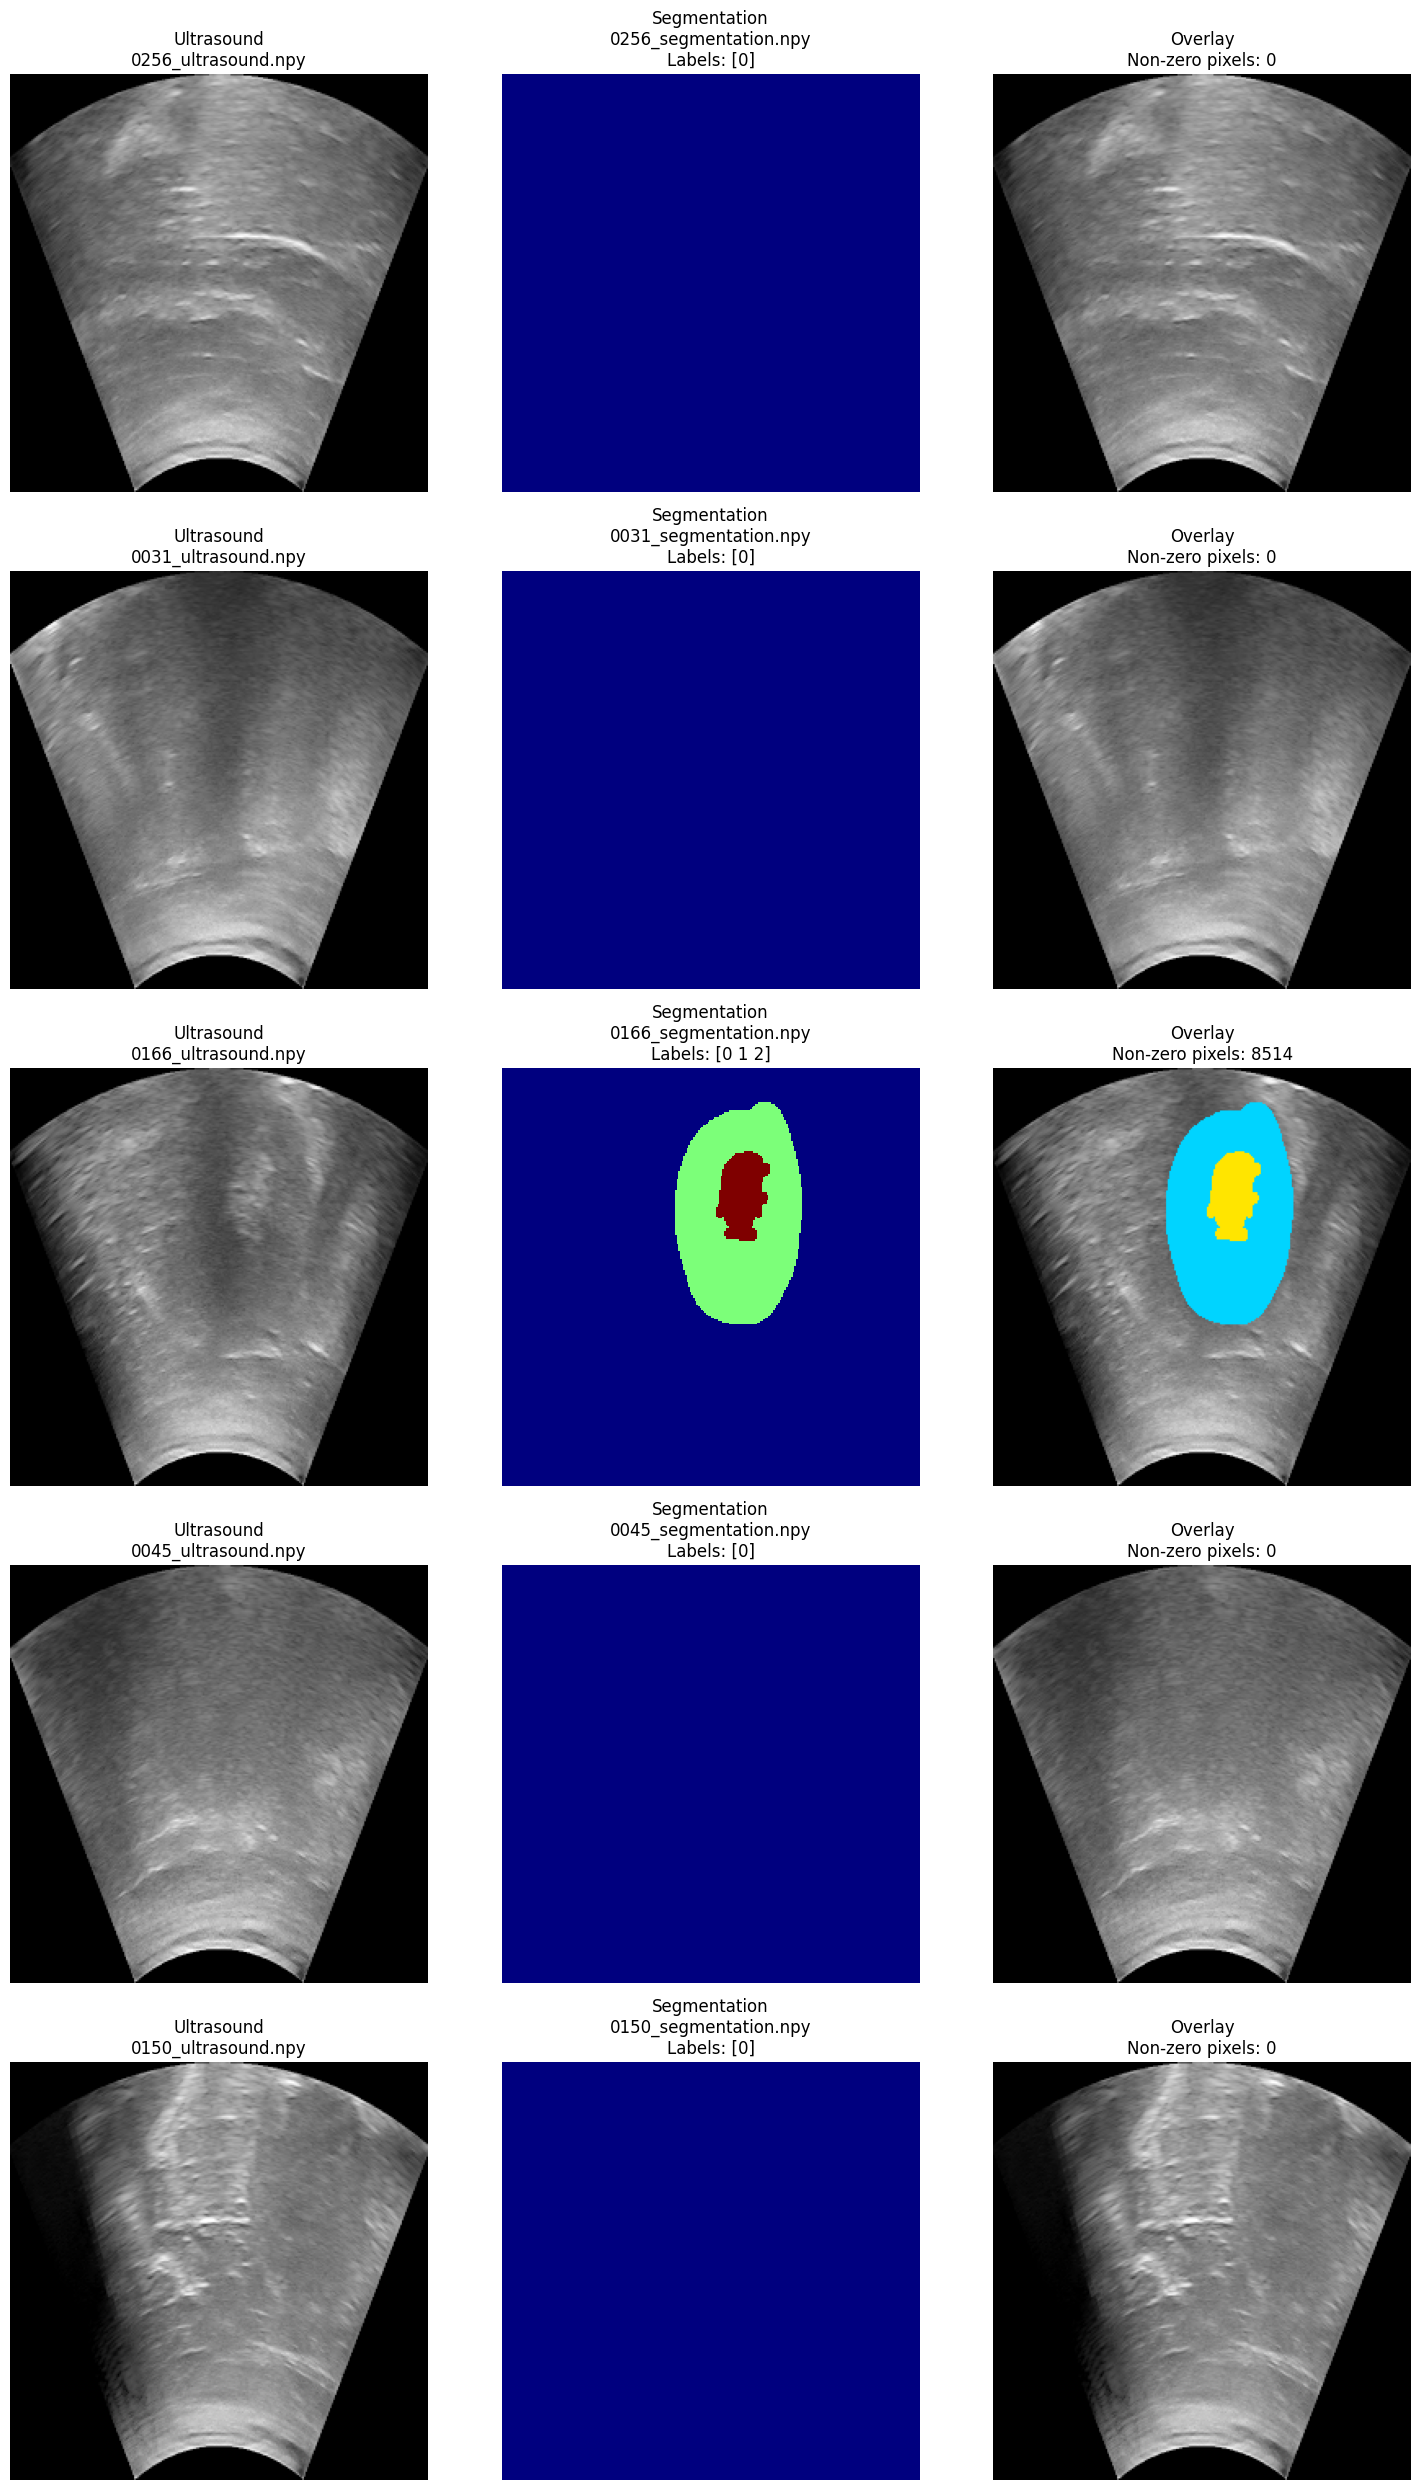

In [6]:
# Display images and segmentations with overlay
if len(img_files) > 0:
    fig, axes = plt.subplots(len(img_files), 3, figsize=(15, 5*len(img_files)))
    if len(img_files) == 1:
        axes = axes.reshape(1, -1)
    
    for idx, (img_file, seg_file) in enumerate(zip(img_files, rand_files[:len(img_files)])):
        try:
            img = np.load(img_file)
            seg = np.load(seg_file)
            
            # Handle different segmentation formats
            if seg.ndim == 3:
                if seg.shape[2] == 1:
                    seg = seg.squeeze()
                else:
                    # Multi-channel: convert to labelmap for visualization
                    seg_vis = np.zeros(seg.shape[:2], dtype=np.uint8)
                    for ch in range(seg.shape[2]):
                        seg_vis[seg[:, :, ch] > 0] = ch + 1
                    seg = seg_vis
            elif seg.ndim > 3:
                seg = seg.squeeze()
            
            # Ensure 2D for display
            if img.ndim > 2:
                img = img.squeeze()
                if img.ndim > 2:
                    img = img[:, :, 0]  # Take first channel
            
            # Check shape compatibility
            if img.shape != seg.shape:
                print(f"⚠️  Shape mismatch for {os.path.basename(seg_file)}:")
                print(f"   Image shape: {img.shape}, Segmentation shape: {seg.shape}")
                # Resize segmentation to match image if needed
                try:
                    from scipy.ndimage import zoom
                    zoom_factors = [img.shape[i] / seg.shape[i] for i in range(2)]
                    seg = zoom(seg, zoom_factors, order=0)  # Nearest neighbor interpolation
                except ImportError:
                    print("   scipy not available, skipping resize")
            
            # Display original image
            axes[idx, 0].imshow(img, cmap='gray')
            axes[idx, 0].set_title(f'Ultrasound\n{os.path.basename(img_file)}')
            axes[idx, 0].axis('off')
            
            # Display segmentation
            axes[idx, 1].imshow(seg, cmap='jet', interpolation='nearest')
            axes[idx, 1].set_title(f'Segmentation\n{os.path.basename(seg_file)}\nLabels: {np.unique(seg)}')
            axes[idx, 1].axis('off')
            
            # Display overlay
            overlay = img.copy()
            if img.dtype != np.uint8:
                overlay = (overlay - overlay.min()) / (overlay.max() - overlay.min() + 1e-8) * 255
                overlay = overlay.astype(np.uint8)
            
            overlay_colored = plt.cm.gray(overlay / 255.0)[:, :, :3]
            seg_mask = seg > 0
            if np.any(seg_mask):
                seg_normalized = seg[seg_mask] / (seg.max() + 1) if seg.max() > 0 else seg[seg_mask]
                overlay_colored[seg_mask] = plt.cm.jet(seg_normalized)[:, :3]
            
            axes[idx, 2].imshow(overlay_colored)
            axes[idx, 2].set_title(f'Overlay\nNon-zero pixels: {np.count_nonzero(seg)}')
            axes[idx, 2].axis('off')
            
        except Exception as e:
            print(f"Error processing {seg_file}: {e}")
            import traceback
            traceback.print_exc()
            axes[idx, 0].text(0.5, 0.5, f'Error loading\n{str(e)}', 
                            ha='center', va='center', transform=axes[idx, 0].transAxes)
            axes[idx, 1].axis('off')
            axes[idx, 2].axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print("No image-segmentation pairs found to visualize.")

## Step 4: Comprehensive verification summary

In [7]:
# Comprehensive check of all segmentation files
print("Running comprehensive verification...\n")

total_files = len(seg_files)
loadable_files = 0
empty_files = 0
no_labels_files = 0
shape_mismatches = 0
missing_images = 0

for seg_file in seg_files:
    # Check if file can be loaded
    seg_arr, error = load_segmentation(seg_file)
    if error:
        continue
    loadable_files += 1
    
    # Check if segmentation is empty
    if seg_arr.size == 0:
        empty_files += 1
        continue
    
    # Check if all zeros
    if np.max(seg_arr) == 0:
        no_labels_files += 1
    
    # Check for corresponding image
    img_file = seg_file.replace("labels", "images").replace("segmentation", "ultrasound").replace("labelmap", "ultrasound")
    if os.path.exists(img_file):
        try:
            img = np.load(img_file)
            if img.ndim > 2:
                img = img.squeeze()
                if img.ndim > 2:
                    img = img[:, :, 0]
            
            seg_2d = seg_arr.squeeze()
            if seg_2d.ndim == 3 and seg_2d.shape[2] == 1:
                seg_2d = seg_2d[:, :, 0]
            
            if img.shape[:2] != seg_2d.shape[:2]:
                shape_mismatches += 1
        except:
            pass
    else:
        missing_images += 1

print(f"Total segmentation files: {total_files}")
print(f"✓ Loadable files: {loadable_files} ({100*loadable_files/total_files:.1f}%)")
print(f"⚠️  Empty files: {empty_files}")
print(f"⚠️  Files with no labels (all zeros): {no_labels_files}")
print(f"⚠️  Shape mismatches with images: {shape_mismatches}")
print(f"⚠️  Missing corresponding images: {missing_images}")

if loadable_files == total_files and empty_files == 0 and no_labels_files == 0:
    print("\n✅ All segmentation files are valid and contain labels!")
elif loadable_files == total_files:
    print("\n✅ All files are loadable, but some may need attention.")
else:
    print(f"\n❌ Some files have issues. {total_files - loadable_files} files could not be loaded.")

Running comprehensive verification...

Total segmentation files: 342
✓ Loadable files: 342 (100.0%)
⚠️  Empty files: 0
⚠️  Files with no labels (all zeros): 232
⚠️  Shape mismatches with images: 0
⚠️  Missing corresponding images: 0

✅ All files are loadable, but some may need attention.
